# Dalle equazioni di Maxwell al tunneling ottico

### Subject: Optics

Percorso didattico che parte dalle **equazioni di Maxwell**, costruisce le soluzioni
ondulatorie (piane, sferiche, cilindriche elicoidali), introduce la **polarizzazione**,
studia l'impatto su un'interfaccia con indice di rifrazione diverso (Fresnel),
mostra l'andamento a **gradini** di $n(z)$ e chiude con il **tunneling ottico**
(riflessione totale frustrata / onde evanescenti).

Ogni sezione combina:
- una breve spiegazione teorica,
- codice eseguibile,
- grafici e tabelle numeriche da interpretare.

Dipendenze: `numpy`, `scipy`, `matplotlib`.

## 0. Setup e costanti

Definiamo le costanti SI e alcune funzioni di utilità per i plot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.special import jv

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Costanti SI
c0 = 299_792_458.0          # m/s
eps0 = 8.854_187_8128e-12   # F/m
mu0 = 4e-7 * np.pi          # H/m
Z0 = np.sqrt(mu0 / eps0)    # impedenza del vuoto ≈ 377 Ω

def set_equal_3d(ax, lim=1.0):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

print(f"c0 = {c0:.3e} m/s")
print(f"Z0 = {Z0:.2f} Ω")
print("Setup pronto.")

c0 = 2.998e+08 m/s
Z0 = 376.73 Ω
Setup pronto.


## 1. Equazioni di Maxwell → equazione delle onde

In un dielettrico lineare, omogeneo, isotropo, senza cariche né correnti libere
($\rho=0$, $\mathbf{J}=0$):

$$
\begin{aligned}
\nabla\cdot\mathbf{E} &= 0, &
\nabla\cdot\mathbf{B} &= 0, \\
\nabla\times\mathbf{E} &= -\partial_t\mathbf{B}, &
\nabla\times\mathbf{B} &= \mu\varepsilon\,\partial_t\mathbf{E}.
\end{aligned}
$$

Prendendo il rotore della legge di Faraday e usando
$\nabla\times(\nabla\times\mathbf{E})=\nabla(\nabla\cdot\mathbf{E})-\nabla^2\mathbf{E}$
si ottiene l'equazione delle onde:

$$
\nabla^2\mathbf{E} - \frac{n^2}{c_0^2}\,\partial_t^2\mathbf{E} = 0,
\qquad n=\sqrt{\varepsilon_r\mu_r}.
$$

La stessa forma vale per $\mathbf{B}$. La velocità di fase è $v=c_0/n$ e
$|\mathbf{B}|=|\mathbf{E}|/v$ per un'onda piana TEM.

Verifica numerica: un'onda piana $E_x=\cos(kz-\omega t)$ soddisfa
$\partial_z^2 E = (n^2/c_0^2)\,\partial_t^2 E$ con $k=n\omega/c_0$.

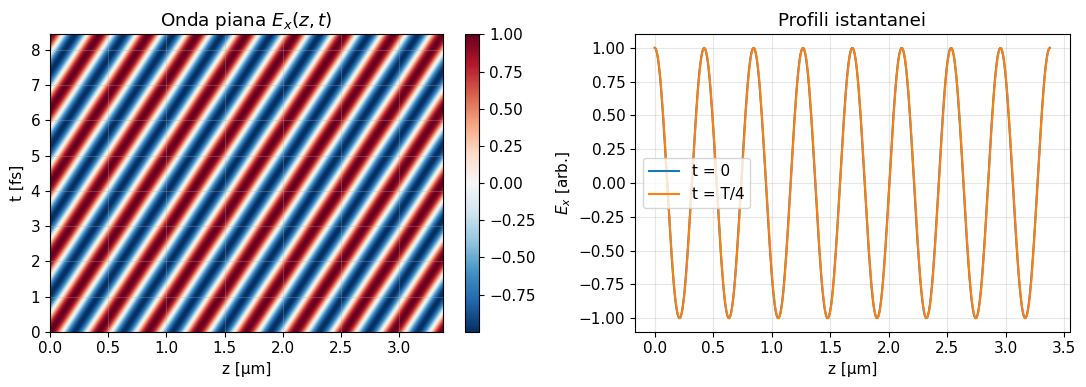

Verifica equazione delle onde (norma residuo / norma ∂²E/∂z²):
  errore relativo ≈ 7.342e-04
  k = 1.489e+07 m⁻¹,  λ_med = 422.00 nm,  v = 0.667 c₀
  |B|/|E| teorico = 1/v = 5.003e-09 s/m


In [2]:
# Onda piana monochromatica: verifica discreta dell'equazione delle onde
n_med = 1.5
lam = 633e-9                 # HeNe, m
omega = 2 * np.pi * c0 / lam
k = n_med * omega / c0
v = c0 / n_med

Nz, Nt = 400, 300
z = np.linspace(0, 8 * lam / n_med, Nz)
t = np.linspace(0, 4 * (2 * np.pi / omega), Nt)
Z, T = np.meshgrid(z, t, indexing="ij")
E = np.cos(k * Z - omega * T)

dz = z[1] - z[0]
dt = t[1] - t[0]
d2E_dz2 = (E[2:, 1:-1] - 2 * E[1:-1, 1:-1] + E[:-2, 1:-1]) / dz**2
d2E_dt2 = (E[1:-1, 2:] - 2 * E[1:-1, 1:-1] + E[1:-1, :-2]) / dt**2
residual = d2E_dz2 - (n_med**2 / c0**2) * d2E_dt2

rel_err = np.linalg.norm(residual) / np.linalg.norm(d2E_dz2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(
    E.T, origin="lower", aspect="auto",
    extent=[z[0] * 1e6, z[-1] * 1e6, t[0] * 1e15, t[-1] * 1e15],
    cmap="RdBu_r",
)
axes[0].set_xlabel("z [μm]")
axes[0].set_ylabel("t [fs]")
axes[0].set_title(r"Onda piana $E_x(z,t)$")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].plot(z * 1e6, E[:, 0], label="t = 0")
axes[1].plot(z * 1e6, E[:, Nt // 4], label="t = T/4")
axes[1].set_xlabel("z [μm]")
axes[1].set_ylabel(r"$E_x$ [arb.]")
axes[1].set_title("Profili istantanei")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Verifica equazione delle onde (norma residuo / norma ∂²E/∂z²):")
print(f"  errore relativo ≈ {rel_err:.3e}")
print(f"  k = {k:.3e} m⁻¹,  λ_med = {2*np.pi/k*1e9:.2f} nm,  v = {v/c0:.3f} c₀")
print(f"  |B|/|E| teorico = 1/v = {1/v:.3e} s/m")

## 2. Onde sferiche: campo elettrico e magnetico

Lontano da una sorgente puntiforme (zona di Fraunhofer / far field) il campo
si comporta come un'**onda sferica** TEM:

$$
\mathbf{E}(\mathbf{r},t) \propto \frac{1}{r}\,
\Re\Bigl\{\mathbf{e}_\theta\, e^{i(kr-\omega t)}\Bigr\},
\qquad
\mathbf{B} = \frac{1}{c_0}\,\hat{\mathbf{r}}\times\mathbf{E}
\quad\text{(nel vuoto)}.
$$

L'ampiezza decade come $1/r$ (conservazione del flusso di energia su sfere
di area $4\pi r^2$). Visualizziamo superfici di fase costante e i vettori
$\mathbf{E}$, $\mathbf{B}$ su una sfera.

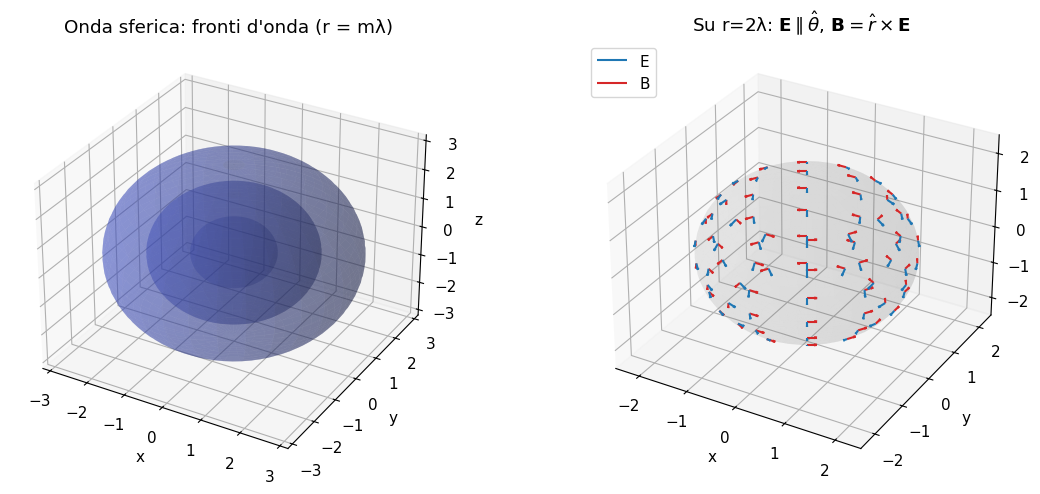

Decadimento sferico (unità normalizzate, E∝1/r, ⟨S⟩∝1/r²):
     r/λ        |E|     ⟨S⟩∝|E|²      4πr²⟨S⟩
     1.0     1.0000       1.0000      12.5664
     2.0     0.5000       0.2500      12.5664
     4.0     0.2500       0.0625      12.5664
     8.0     0.1250       0.0156      12.5664
→ il flusso attraverso sfere concentriche è costante (conservazione energia).


In [3]:
# Far-field di un dipolo lungo z: polarizzazione e_θ
lam0 = 1.0  # unità normalizzate: λ = 1
k0 = 2 * np.pi / lam0

# Superfici di fase: sfere di raggio r_m = m λ
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

u = np.linspace(0, np.pi, 40)
v = np.linspace(0, 2 * np.pi, 60)
U, V = np.meshgrid(u, v)

for m, alpha in [(1, 0.15), (2, 0.25), (3, 0.35)]:
    r = m * lam0
    X = r * np.sin(U) * np.cos(V)
    Y = r * np.sin(U) * np.sin(V)
    Z = r * np.cos(U)
    phase = (k0 * r) % (2 * np.pi)
    color = cm.coolwarm(phase / (2 * np.pi))
    ax1.plot_surface(X, Y, Z, color=color, alpha=alpha, linewidth=0)

ax1.set_title("Onda sferica: fronti d'onda (r = mλ)")
set_equal_3d(ax1, 3.2)

# Campi E, B su una sfera di raggio 2λ (campione di punti)
r_s = 2.0
theta = np.linspace(0.25 * np.pi, 0.75 * np.pi, 6)
phi = np.linspace(0, 2 * np.pi, 12, endpoint=False)
TH, PH = np.meshgrid(theta, phi)
xs = r_s * np.sin(TH) * np.cos(PH)
ys = r_s * np.sin(TH) * np.sin(PH)
zs = r_s * np.cos(TH)

# Versori sferici
er_x, er_y, er_z = xs / r_s, ys / r_s, zs / r_s
# e_θ = (cosθ cosφ, cosθ sinφ, -sinθ)
e_th_x = np.cos(TH) * np.cos(PH)
e_th_y = np.cos(TH) * np.sin(PH)
e_th_z = -np.sin(TH)
# e_φ = (-sinφ, cosφ, 0)
e_ph_x = -np.sin(PH)
e_ph_y = np.cos(PH)
e_ph_z = np.zeros_like(PH)

E0 = 0.35 / r_s  # 1/r
Ex, Ey, Ez = E0 * e_th_x, E0 * e_th_y, E0 * e_th_z
# B = (1/c) r̂ × E  → in unità c=1: B = r̂ × E
Bx = er_y * Ez - er_z * Ey
By = er_z * Ex - er_x * Ez
Bz = er_x * Ey - er_y * Ex

# Sfera di supporto
Us, Vs = np.meshgrid(np.linspace(0, np.pi, 30), np.linspace(0, 2*np.pi, 40))
ax2.plot_surface(
    r_s * np.sin(Us) * np.cos(Vs),
    r_s * np.sin(Us) * np.sin(Vs),
    r_s * np.cos(Us),
    alpha=0.08, color="gray", linewidth=0,
)
ax2.quiver(xs, ys, zs, Ex, Ey, Ez, color="C0", length=1.0, normalize=False, label="E")
ax2.quiver(xs, ys, zs, Bx, By, Bz, color="C3", length=1.0, normalize=False, label="B")
ax2.set_title(r"Su r=2λ: $\mathbf{E}\parallel\hat{\theta}$, $\mathbf{B}=\hat{r}\times\mathbf{E}$")
set_equal_3d(ax2, 2.5)
ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Tabella numerica: decadimento 1/r dell'ampiezza e densità di Poynting ~ 1/r²
print("Decadimento sferico (unità normalizzate, E∝1/r, ⟨S⟩∝1/r²):")
print(f"{'r/λ':>8} {'|E|':>10} {'⟨S⟩∝|E|²':>12} {'4πr²⟨S⟩':>12}")
for m in (1, 2, 4, 8):
    Eamp = 1.0 / m
    S = Eamp**2
    flux = 4 * np.pi * m**2 * S
    print(f"{m:8.1f} {Eamp:10.4f} {S:12.4f} {flux:12.4f}")
print("→ il flusso attraverso sfere concentriche è costante (conservazione energia).")

## 3. Onde cilindriche elicoidali

In coordinate cilindriche $(\rho,\varphi,z)$ una soluzione monochromatica tipica
è un **fascio di Bessel** (o, più in generale, un'onda cilindrica) con momento
angolare orbitale $\ell$:

$$
\psi(\rho,\varphi,z) = J_{|\ell|}(k_\perp\rho)\,
e^{i\ell\varphi}\, e^{ik_z z},
\qquad k_\perp^2 + k_z^2 = k^2.
$$

La fase $e^{i\ell\varphi}$ è un'**elica**: avanzando di $\Delta\varphi=2\pi$
si accumula una differenza di fase $2\pi\ell$ (carica topologica $\ell$).

Per un campo TEM localmente polarizzato, $\mathbf{B}\perp\mathbf{E}$ e
entrambi sono ortogonali alla direzione di propagazione locale.

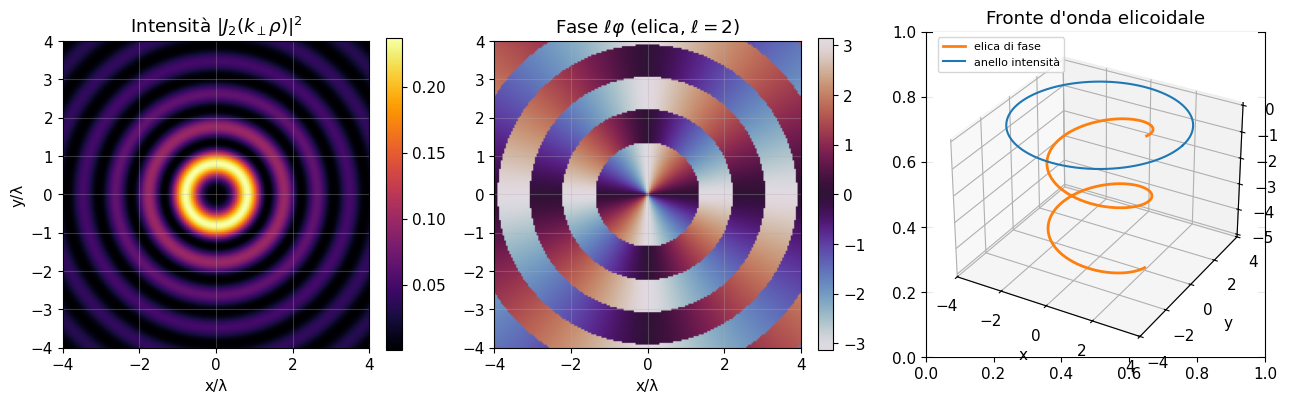

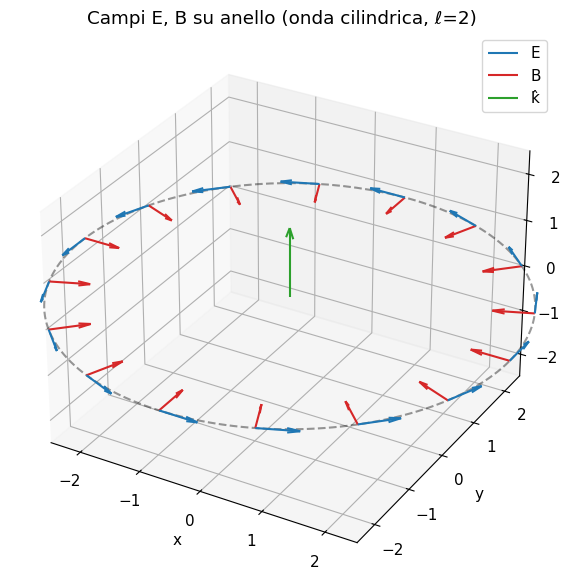

Parametri: ℓ=2, k⊥/k=0.60, kz/k=0.80
Raggio anello di intensità (max |J_ℓ|²) ≈ 3.494 λ
Passo elicoidale del fronte (Δz per Δφ=2π): 2.500 λ


In [4]:
ell = 2          # carica topologica (OAM)
k = 2 * np.pi    # λ = 1
k_perp = 0.6 * k
k_z = np.sqrt(k**2 - k_perp**2)

# Griglia trasversa
N = 180
xy = np.linspace(-4, 4, N)
X, Y = np.meshgrid(xy, xy)
rho = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)
amp = jv(abs(ell), k_perp * rho)
phase = ell * phi
field = amp * np.exp(1j * phase)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
im0 = axes[0].imshow(np.abs(field)**2, extent=[-4, 4, -4, 4], origin="lower", cmap="inferno")
axes[0].set_title(rf"Intensità $|J_{{{ell}}}(k_\perp\rho)|^2$")
axes[0].set_xlabel("x/λ"); axes[0].set_ylabel("y/λ")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.angle(field), extent=[-4, 4, -4, 4], origin="lower", cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[1].set_title(rf"Fase $\ell\varphi$ (elica, $\ell={ell}$)")
axes[1].set_xlabel("x/λ")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

# Superficie di fase elicoidale in 3D (iso-fase)
ax3 = fig.add_subplot(133, projection="3d")
# Campione di punti lungo l'elica di fase costante + z
phi_h = np.linspace(0, 4 * np.pi, 400)
rho_h = 2.0
z_h = -(ell / k_z) * phi_h   # fronte elicoidale: ℓφ + kz z = cost ⇒ z = -ℓφ/kz
xh, yh = rho_h * np.cos(phi_h), rho_h * np.sin(phi_h)
ax3.plot(xh, yh, z_h, color="C1", lw=2, label="elica di fase")
# Anelli di intensità a z=0
th = np.linspace(0, 2*np.pi, 200)
r_peak = (abs(ell) + 0.5) / k_perp if ell != 0 else 0.0
# stima grezza del primo massimo di J_ℓ
from scipy.optimize import minimize_scalar
res = minimize_scalar(lambda r: -abs(jv(abs(ell), k_perp * r))**2, bounds=(0.1, 6), method="bounded")
r_peak = res.x
ax3.plot(r_peak*np.cos(th), r_peak*np.sin(th), 0*th, "C0", lw=1.5, label="anello intensità")
ax3.set_title("Fronte d'onda elicoidale")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Campi E, B trasversi su un anello (polarizzazione lineare locale lungo φ̂)
phi_s = np.linspace(0, 2*np.pi, 16, endpoint=False)
xs = r_peak * np.cos(phi_s)
ys = r_peak * np.sin(phi_s)
zs = np.zeros_like(xs)
# E ~ e_φ (tangenziale), B ~ -e_ρ (radiale) per propagazione +z locale semplificata
Ex = -np.sin(phi_s)
Ey =  np.cos(phi_s)
Ez = np.zeros_like(xs)
Bx = -np.cos(phi_s)
By = -np.sin(phi_s)
Bz = np.zeros_like(xs)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(r_peak*np.cos(th), r_peak*np.sin(th), 0*th, "k--", alpha=0.4)
ax.quiver(xs, ys, zs, Ex, Ey, Ez, color="C0", length=0.6, normalize=True, label="E")
ax.quiver(xs, ys, zs, Bx, By, Bz, color="C3", length=0.6, normalize=True, label="B")
# freccia k
ax.quiver(0, 0, 0, 0, 0, 1.5, color="C2", arrow_length_ratio=0.15, label="k̂")
ax.set_title(rf"Campi E, B su anello (onda cilindrica, ℓ={ell})")
set_equal_3d(ax, 2.5)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Parametri: ℓ={ell}, k⊥/k={k_perp/k:.2f}, kz/k={k_z/k:.2f}")
print(f"Raggio anello di intensità (max |J_ℓ|²) ≈ {r_peak:.3f} λ")
print(f"Passo elicoidale del fronte (Δz per Δφ=2π): {abs(2*np.pi*ell/k_z):.3f} λ" if ell else "ℓ=0: fronte piano")

## 4. Campi polarizzati

Un'onda piana che si propaga lungo $+z$ ha solo componenti trasverse.
Lo stato di polarizzazione è il vettore complesso $(E_x, E_y)$:

| Polarizzazione | $(E_x, E_y)$ |
|----------------|--------------|
| Lineare H | $(1,0)$ |
| Lineare a 45° | $(1,1)/\sqrt{2}$ |
| Circolare RCP | $(1,-i)/\sqrt{2}$ |
| Circolare LCP | $(1,+i)/\sqrt{2}$ |

$\mathbf{B}=\hat{z}\times\mathbf{E}/c$. Disegnamo le traiettorie tipiche
del vettore $\mathbf{E}(t)$ nel piano $xy$.

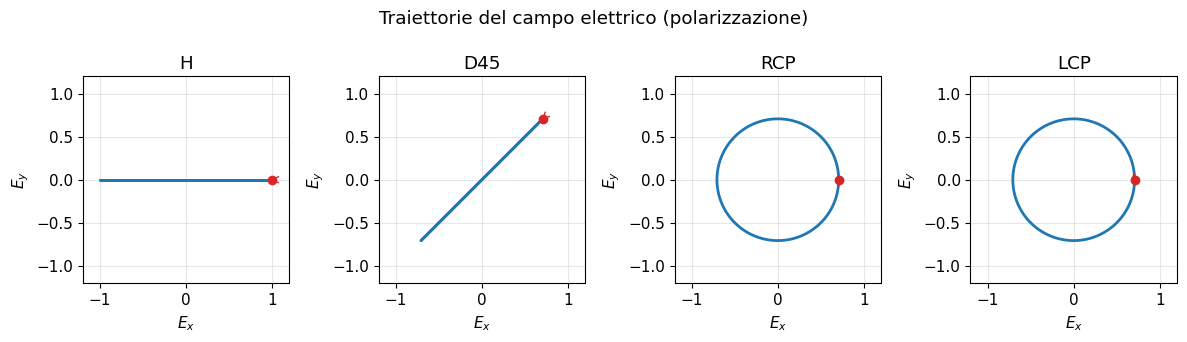

Campione RCP: E ⊥ B e |B|=|E| (unità c=1)
     t/T       Ex       Ey       Bx       By        E·B    |B|-|E|
    0.00    0.707   -0.000    0.000    0.707   0.00e+00   0.00e+00
    0.17    0.351   -0.614    0.614    0.351   0.00e+00   0.00e+00
    0.33   -0.358   -0.610    0.610   -0.358   0.00e+00   0.00e+00
    0.50   -0.707    0.007   -0.007   -0.707   0.00e+00   0.00e+00
    0.67   -0.345    0.617   -0.617   -0.345   0.00e+00   0.00e+00
    0.84    0.364    0.606   -0.606    0.364   0.00e+00   0.00e+00


In [5]:
def jones(name: str) -> np.ndarray:
    return {
        "H": np.array([1.0, 0.0], dtype=complex),
        "V": np.array([0.0, 1.0], dtype=complex),
        "D45": np.array([1.0, 1.0], dtype=complex) / np.sqrt(2),
        "RCP": np.array([1.0, -1j], dtype=complex) / np.sqrt(2),
        "LCP": np.array([1.0, +1j], dtype=complex) / np.sqrt(2),
    }[name]

t = np.linspace(0, 2 * np.pi, 300)
names = ["H", "D45", "RCP", "LCP"]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, name in zip(axes, names):
    J = jones(name)
    Ex = np.real(J[0] * np.exp(-1j * t))
    Ey = np.real(J[1] * np.exp(-1j * t))
    ax.plot(Ex, Ey, lw=2)
    ax.scatter([Ex[0]], [Ey[0]], c="C3", zorder=3, label="t=0")
    # freccia verso t piccolo
    ax.annotate("", xy=(Ex[8], Ey[8]), xytext=(Ex[0], Ey[0]),
                arrowprops=dict(arrowstyle="->", color="C3"))
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(r"$E_x$"); ax.set_ylabel(r"$E_y$")
    ax.set_title(name)
plt.suptitle("Traiettorie del campo elettrico (polarizzazione)", y=1.02)
plt.tight_layout()
plt.show()

# Relazione E–B istantanea per RCP
J = jones("RCP")
Ex = np.real(J[0] * np.exp(-1j * t))
Ey = np.real(J[1] * np.exp(-1j * t))
# B = ẑ × E / c  (c=1): Bx = -Ey, By = Ex
Bx, By = -Ey, Ex
print("Campione RCP: E ⊥ B e |B|=|E| (unità c=1)")
print(f"{'t/T':>8} {'Ex':>8} {'Ey':>8} {'Bx':>8} {'By':>8} {'E·B':>10} {'|B|-|E|':>10}")
for i in range(0, len(t), 50):
    EdotB = Ex[i]*Bx[i] + Ey[i]*By[i]
    dmag = np.hypot(Bx[i], By[i]) - np.hypot(Ex[i], Ey[i])
    print(f"{t[i]/(2*np.pi):8.2f} {Ex[i]:8.3f} {Ey[i]:8.3f} {Bx[i]:8.3f} {By[i]:8.3f} {EdotB:10.2e} {dmag:10.2e}")

## 5. Impatto su un piano: interfaccia con $n$ diverso (Fresnel)

All'interfaccia $z=0$ tra due dielettrici ($n_1\to n_2$), continuità di
$\mathbf{E}_\parallel$ e $\mathbf{H}_\parallel$ implica i coefficienti di
**Fresnel**. Per incidenza normale:

$$
r = \frac{n_1-n_2}{n_1+n_2},\qquad
t = \frac{2n_1}{n_1+n_2}.
$$

A angolo $\theta_1$ distinguendo polarizzazione $s$ (TE, $\mathbf{E}\perp$ piano
di incidenza) e $p$ (TM):

$$
\begin{aligned}
r_s &= \frac{n_1\cos\theta_1 - n_2\cos\theta_2}{n_1\cos\theta_1 + n_2\cos\theta_2}, &
r_p &= \frac{n_2\cos\theta_1 - n_1\cos\theta_2}{n_2\cos\theta_1 + n_1\cos\theta_2}, \\
t_s &= \frac{2n_1\cos\theta_1}{n_1\cos\theta_1 + n_2\cos\theta_2}, &
t_p &= \frac{2n_1\cos\theta_1}{n_2\cos\theta_1 + n_1\cos\theta_2},
\end{aligned}
$$

con $\theta_2$ da Snell: $n_1\sin\theta_1=n_2\sin\theta_2$.

Le riflettanze in potenza sono $R_{s,p}=|r_{s,p}|^2$.
L'angolo di Brewster ($r_p=0$) e l'angolo critico (TIR se $n_1>n_2$)
separano regimi qualitativamente diversi — e la polarizzazione conta.

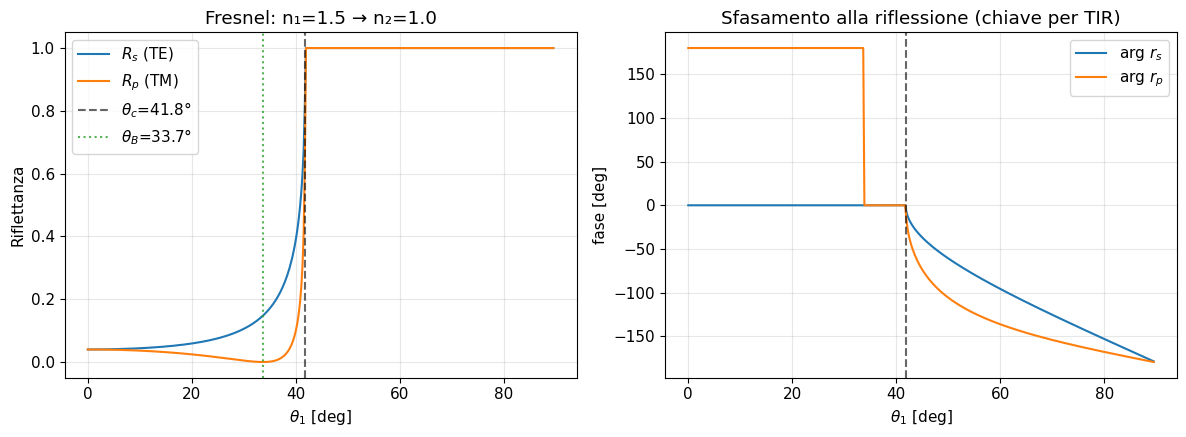

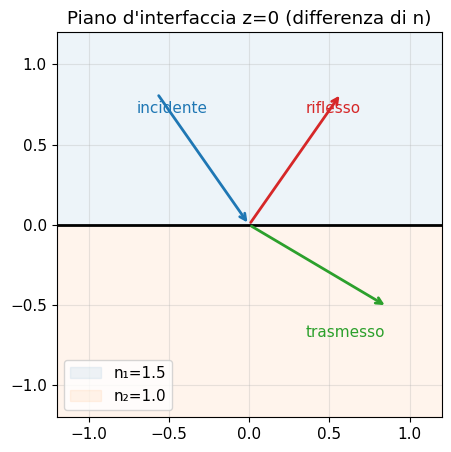

Angolo critico θ_c = 41.81°  |  Brewster θ_B = 33.69°

 θ [deg]       Rs       Rp       Ts       Tp    Rs+Ts
     0.0   0.0400   0.0400   0.9600   0.9600   1.0000
    20.0   0.0591   0.0244   0.9409   0.9756   1.0000
    40.0   0.3905   0.1001   0.6095   0.8999   1.0000
    33.7   0.1479   0.0000   0.8521   1.0000   1.0000
    41.3   0.6076   0.3180   0.3924   0.6820   1.0000
    46.8   1.0000   1.0000   0.0000   0.0000   1.0000
    80.0   1.0000   1.0000   0.0000   0.0000   1.0000

Nota: sotto θ_c, R+T≈1; oltre θ_c (TIR) R→1 e compare un'onda evanescente in n₂.


In [6]:
def fresnel(n1, n2, theta1_deg):
    th1 = np.deg2rad(np.asarray(theta1_deg, dtype=float))
    # cosθ2 da Snell (forma robusta anche in TIR)
    sin_th2 = (n1 / n2) * np.sin(th1)
    cos_th1 = np.cos(th1)
    cos_th2 = np.sqrt(1.0 - sin_th2**2 + 0j)
    rs = (n1*cos_th1 - n2*cos_th2) / (n1*cos_th1 + n2*cos_th2)
    rp = (n2*cos_th1 - n1*cos_th2) / (n2*cos_th1 + n1*cos_th2)
    ts = (2*n1*cos_th1) / (n1*cos_th1 + n2*cos_th2)
    tp = (2*n1*cos_th1) / (n2*cos_th1 + n1*cos_th2)
    return rs, rp, ts, tp

def power_R_T(n1, n2, theta1_deg, rs, rp, ts, tp):
    th1 = np.deg2rad(np.asarray(theta1_deg, dtype=float))
    sin_th2 = (n1 / n2) * np.sin(th1)
    cos_th1 = np.cos(th1)
    cos_th2 = np.sqrt(1.0 - sin_th2**2 + 0j)
    Rs, Rp = np.abs(rs)**2, np.abs(rp)**2
    # trasmittanza in potenza (flusso di Poynting normale)
    factor = (n2 * np.real(cos_th2)) / (n1 * cos_th1)
    Ts = factor * np.abs(ts)**2
    Tp = factor * np.abs(tp)**2
    return Rs, Rp, Ts, Tp

n1, n2 = 1.50, 1.00   # vetro → aria (possibile TIR)
angles = np.linspace(0, 89.5, 400)
rs, rp, ts, tp = fresnel(n1, n2, angles)
Rs, Rp, Ts, Tp = power_R_T(n1, n2, angles, rs, rp, ts, tp)

theta_c = np.rad2deg(np.arcsin(n2 / n1))
# Brewster per interfaccia: arctan(n2/n1) dall'aria, qui da n1: arctan(n2/n1)
theta_B = np.rad2deg(np.arctan(n2 / n1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(angles, Rs, label=r"$R_s$ (TE)")
axes[0].plot(angles, Rp, label=r"$R_p$ (TM)")
axes[0].axvline(theta_c, color="k", ls="--", alpha=0.6, label=rf"$\theta_c$={theta_c:.1f}°")
axes[0].axvline(theta_B, color="C2", ls=":", alpha=0.8, label=rf"$\theta_B$={theta_B:.1f}°")
axes[0].set_xlabel(r"$\theta_1$ [deg]")
axes[0].set_ylabel("Riflettanza")
axes[0].set_title(rf"Fresnel: n₁={n1} → n₂={n2}")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

axes[1].plot(angles, np.angle(rs, deg=True), label=r"arg $r_s$")
axes[1].plot(angles, np.angle(rp, deg=True), label=r"arg $r_p$")
axes[1].axvline(theta_c, color="k", ls="--", alpha=0.6)
axes[1].set_xlabel(r"$\theta_1$ [deg]")
axes[1].set_ylabel("fase [deg]")
axes[1].set_title("Sfasamento alla riflessione (chiave per TIR)")
axes[1].legend()
plt.tight_layout()
plt.show()

# Schema geometrico: raggio incidente / riflesso / trasmesso
fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(0, color="k", lw=2)
ax.fill_between([-1.2, 1.2], 0, 1.2, color="C0", alpha=0.08, label=f"n₁={n1}")
ax.fill_between([-1.2, 1.2], -1.2, 0, color="C1", alpha=0.08, label=f"n₂={n2}")
th_demo = np.deg2rad(35)
ax.annotate("", xy=(0, 0), xytext=(-np.sin(th_demo), np.cos(th_demo)),
            arrowprops=dict(arrowstyle="->", color="C0", lw=2))
ax.text(-0.7, 0.7, "incidente", color="C0")
ax.annotate("", xy=(np.sin(th_demo), np.cos(th_demo)), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="C3", lw=2))
ax.text(0.35, 0.7, "riflesso", color="C3")
# trasmesso (se sotto critico)
sin_t = n1/n2 * np.sin(th_demo)
if abs(sin_t) <= 1:
    th2 = np.arcsin(sin_t)
    ax.annotate("", xy=(np.sin(th2), -np.cos(th2)), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="C2", lw=2))
    ax.text(0.35, -0.7, "trasmesso", color="C2")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_title("Piano d'interfaccia z=0 (differenza di n)")
ax.legend(loc="lower left")
plt.show()

# Tabella numerica: confronto s vs p
print(f"Angolo critico θ_c = {theta_c:.2f}°  |  Brewster θ_B = {theta_B:.2f}°")
print(f"\n{'θ [deg]':>8} {'Rs':>8} {'Rp':>8} {'Ts':>8} {'Tp':>8} {'Rs+Ts':>8}")
for th in (0, 20, 40, theta_B, theta_c - 0.5, theta_c + 5, 80):
    rs_, rp_, ts_, tp_ = fresnel(n1, n2, th)
    Rs_, Rp_, Ts_, Tp_ = power_R_T(n1, n2, th, rs_, rp_, ts_, tp_)
    # in TIR, T→0 e R→1
    print(f"{th:8.1f} {Rs_:8.4f} {Rp_:8.4f} {np.real(Ts_):8.4f} {np.real(Tp_):8.4f} {Rs_+np.real(Ts_):8.4f}")
print("\nNota: sotto θ_c, R+T≈1; oltre θ_c (TIR) R→1 e compare un'onda evanescente in n₂.")

## 6. Indice di rifrazione a gradini (in funzione del passo)

In molti dispositivi (fibre step-index, stack dielettrici, rivestimenti
antiriflesso) $n$ non varia in continuo ma a **passi** lungo $z$:

$$
n(z) = n_j \quad\text{per}\quad z_j \le z < z_{j+1}.
$$

Confrontiamo tre profili:
1. **singolo gradino** (interfaccia abrupta),
2. **multistrato a gradini** (es. 4 strati),
3. **approssimazione a gradini** di un profilo graduato (sigmoid → N passi).

Al crescere del numero di passi, un profilo a gradini approssima un
gradiente continuo: utile per capire come il “passo” discreto controlli
riflessione e fase ottica $\phi = k_0\int n(z)\,dz$.

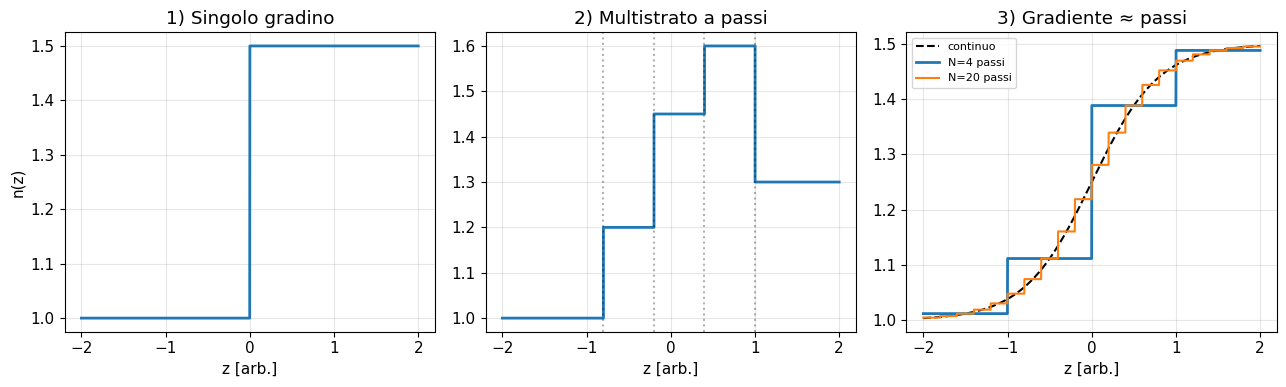

Cammino ottico ∫ n dz su z∈[-2,2]:
  singolo gradino     OPL = 5.0000  → fase k0·OPL = 31.416 rad
  multistrato         OPL = 5.0502  → fase k0·OPL = 31.732 rad
  continuo            OPL = 5.0000  → fase k0·OPL = 31.416 rad
  N=4                 OPL = 5.0000  → fase k0·OPL = 31.416 rad
  N=20                OPL = 5.0000  → fase k0·OPL = 31.416 rad

Riflettanza locale |r|² a ogni passo del multistrato (incidenza normale):
 interfaccia      n_a→n_b          R
       -0.80 1.00→1.20     0.0083
       -0.20 1.20→1.45     0.0089
       +0.40 1.45→1.60     0.0024
       +1.00 1.60→1.30     0.0107


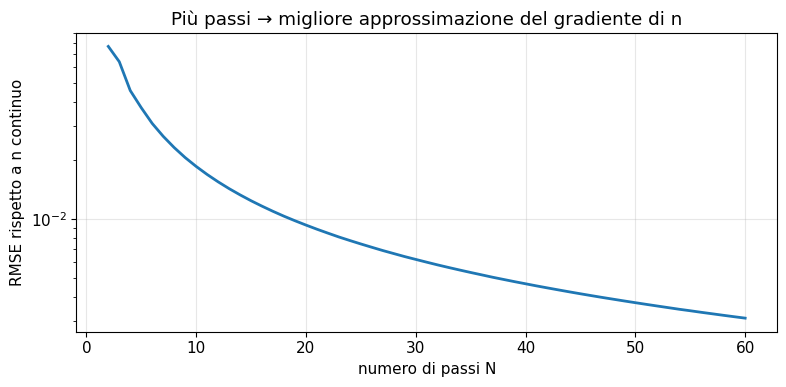

In [7]:
def n_step_single(z, z0=0.0, n_L=1.0, n_R=1.5):
    return np.where(z < z0, n_L, n_R)

def n_multilayer(z, edges, values):
    # edges monotoni; values ha lunghezza len(edges)-1
    n = np.full_like(z, values[-1], dtype=float)
    for i in range(len(values)):
        mask = (z >= edges[i]) & (z < edges[i + 1])
        n[mask] = values[i]
    return n

def n_graded_continuous(z, z0=0.0, width=0.4, n_L=1.0, n_R=1.5):
    # sigmoid
    return n_L + (n_R - n_L) / (1 + np.exp(-(z - z0) / width))

def n_graded_stepped(z, n_steps, z_min=-2, z_max=2, n_L=1.0, n_R=1.5, width=0.4):
    edges = np.linspace(z_min, z_max, n_steps + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    values = n_graded_continuous(centers, width=width, n_L=n_L, n_R=n_R)
    return n_multilayer(z, edges, values), edges, values

z = np.linspace(-2, 2, 2000)
n1p = n_step_single(z)
edges_ml = np.array([-2, -0.8, -0.2, 0.4, 1.0, 2.0])
vals_ml = np.array([1.0, 1.2, 1.45, 1.6, 1.3])
n2p = n_multilayer(z, edges_ml, vals_ml)
n_cont = n_graded_continuous(z)
n_s4, e4, v4 = n_graded_stepped(z, 4)
n_s20, e20, v20 = n_graded_stepped(z, 20)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(z, n1p, lw=2)
axes[0].set_title("1) Singolo gradino")
axes[0].set_xlabel("z [arb.]"); axes[0].set_ylabel("n(z)")

axes[1].plot(z, n2p, lw=2, drawstyle="steps-post")
for e in edges_ml[1:-1]:
    axes[1].axvline(e, color="k", ls=":", alpha=0.3)
axes[1].set_title("2) Multistrato a passi")
axes[1].set_xlabel("z [arb.]")

axes[2].plot(z, n_cont, "k--", lw=1.5, label="continuo")
axes[2].plot(z, n_s4, lw=2, label="N=4 passi")
axes[2].plot(z, n_s20, lw=1.5, label="N=20 passi")
axes[2].set_title("3) Gradiente ≈ passi")
axes[2].set_xlabel("z [arb.]")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Fase ottica accumulata e riflessione di Fresnel equivalente a ciascun gradino
k0 = 2 * np.pi  # λ=1
def optical_path(z, n):
    return np.trapezoid(n, z)

print("Cammino ottico ∫ n dz su z∈[-2,2]:")
for label, nprof in [("singolo gradino", n1p), ("multistrato", n2p),
                     ("continuo", n_cont), ("N=4", n_s4), ("N=20", n_s20)]:
    print(f"  {label:18s}  OPL = {optical_path(z, nprof):.4f}  → fase k0·OPL = {k0*optical_path(z, nprof):.3f} rad")

# Riflettanza di ogni interfaccia del multistrato (incidenza normale)
print("\nRiflettanza locale |r|² a ogni passo del multistrato (incidenza normale):")
print(f"{'interfaccia':>12} {'n_a→n_b':>12} {'R':>10}")
for i in range(len(vals_ml) - 1):
    na, nb = vals_ml[i], vals_ml[i + 1]
    R = abs((na - nb) / (na + nb))**2
    print(f"{edges_ml[i+1]:+12.2f} {na:.2f}→{nb:.2f} {R:10.4f}")

# Errore L2 nell'approssimare il continuo con N passi
Ns = np.arange(2, 61)
err = []
for N in Ns:
    ns, _, _ = n_graded_stepped(z, int(N))
    err.append(np.sqrt(np.mean((ns - n_cont)**2)))
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(Ns, err, lw=2)
ax.set_xlabel("numero di passi N")
ax.set_ylabel(r"RMSE rispetto a n continuo")
ax.set_title("Più passi → migliore approssimazione del gradiente di n")
plt.tight_layout()
plt.show()

## 7. Tunneling ottico (riflessione totale frustrata)

Oltre l'angolo critico, nel mezzo meno denso il campo non propaga: è
**evanescente**,

$$
E(z) \propto e^{-\kappa z},
\qquad
\kappa = k_0\sqrt{n_1^2\sin^2\theta_1 - n_2^2}.
$$

Se a distanza $d$ (gap) si pone un terzo mezzo con $n_3\approx n_1$,
l'onda evanescente può “accoppiare” energia oltre il gap: **tunneling ottico**
(frustrated total internal reflection, FTIR).

Modello a tre strati (incidenza $s$, barriera di aria):

$$
n_1 \;\Big|\; n_2\text{ (gap, spessore }d\text{)} \;\Big|\; n_3
$$

Calcoliamo la trasmittanza $T(d)$ con il metodo della matrice di trasferimento
e confrontiamola con la stima WKB / esponenziale $T\sim e^{-2\kappa d}$.

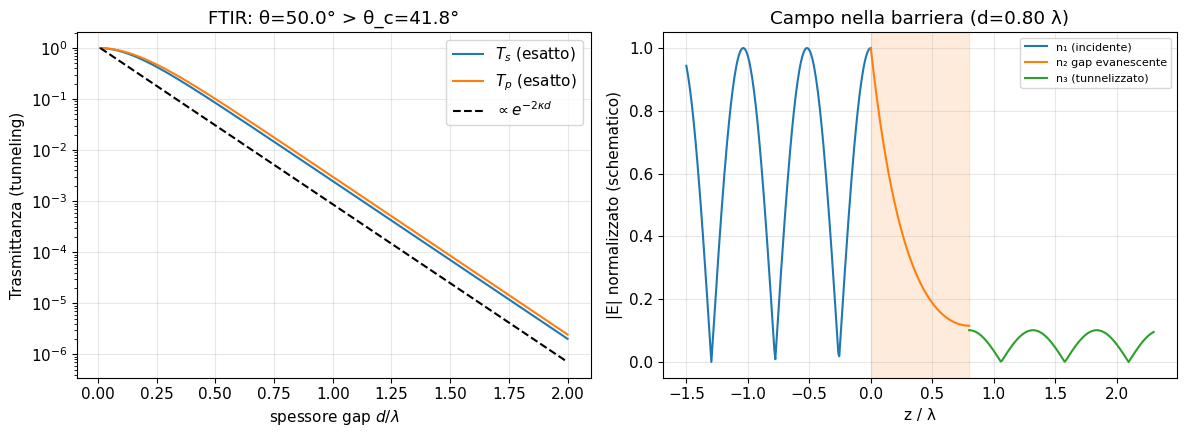

θ_c = 41.81°,  θ = 50.0°,  κ = 5.618e+06 m⁻¹
lunghezza di decadimento 1/κ = 178.00 nm = 0.281 λ

     d/λ          T_s          T_p  e^{-2κd} (norm)
    0.05   9.5978e-01   9.6666e-01       7.5114e-01
    0.10   8.5252e-01   8.7537e-01       5.2635e-01
    0.25   4.2728e-01   4.7548e-01       1.8111e-01
    0.50   8.4453e-02   1.0079e-01       3.0598e-02
    1.00   2.4828e-03   3.0152e-03       8.7343e-04
    1.50   7.0930e-05   8.6186e-05       2.4932e-05

Interpretazione: aumentando il gap, T cade quasi esponenzialmente —
è l'analogo ottico del tunneling quantistico attraverso una barriera.


In [8]:
def kappa_evan(n1, n2, theta1_deg, lam=633e-9):
    k0 = 2 * np.pi / lam
    th = np.deg2rad(theta1_deg)
    inside = n1**2 * np.sin(th)**2 - n2**2
    return k0 * np.sqrt(inside), k0

def transfer_matrix_slab(n1, n2, n3, theta1_deg, d, lam=633e-9, pol="s"):
    # T e R in potenza per slab n2 di spessore d (TE o TM)
    k0 = 2 * np.pi / lam
    th1 = np.deg2rad(theta1_deg)
    # componenti parallele / normali
    kx = n1 * k0 * np.sin(th1)
    def kz(n):
        return np.sqrt((n * k0)**2 - kx**2 + 0j)

    kz1, kz2, kz3 = kz(n1), kz(n2), kz(n3)
    # impedenza relativa per matching: TE usa kz/μ ≈ kz; TM usa n²/kz
    if pol == "s":
        p1, p2, p3 = kz1, kz2, kz3
    else:
        p1, p2, p3 = (n1**2) / kz1, (n2**2) / kz2, (n3**2) / kz3

    # matrice di propagazione nello slab + interfacce (forma standard)
    delta = kz2 * d
    M11 = np.cos(delta)
    M12 = -1j * np.sin(delta) / p2
    M21 = -1j * p2 * np.sin(delta)
    M22 = np.cos(delta)

    # coefficienti da matching con p1, p3
    # [1+r, p1(1-r)]^T collegato a t via M
    # formula chiusa:
    num_r = (M11 + M12*p3)*p1 - (M21 + M22*p3)
    den_r = (M11 + M12*p3)*p1 + (M21 + M22*p3)
    r = num_r / den_r
    t = (2 * p1) / den_r
    R = np.abs(r)**2
    # flusso: Re(p) — per mezzi non assorbenti
    T = (np.real(p3) / np.real(p1)) * np.abs(t)**2
    return R, T, r, t

n1 = n3 = 1.50
n2 = 1.00
theta = 50.0  # > θ_c ≈ 41.8°
lam = 633e-9
kap, k0 = kappa_evan(n1, n2, theta, lam)
theta_c = np.rad2deg(np.arcsin(n2 / n1))
assert theta > theta_c

d_over_lam = np.linspace(0.01, 2.0, 200)
d = d_over_lam * lam
T_s = np.array([transfer_matrix_slab(n1, n2, n3, theta, di, lam, "s")[1] for di in d])
T_p = np.array([transfer_matrix_slab(n1, n2, n3, theta, di, lam, "p")[1] for di in d])
T_approx = np.exp(-2 * kap * d)
T_approx = T_approx * (np.real(T_s[0]) / T_approx[0])  # allinea a T_s(d min)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].semilogy(d_over_lam, np.real(T_s), label=r"$T_s$ (esatto)")
axes[0].semilogy(d_over_lam, np.real(T_p), label=r"$T_p$ (esatto)")
axes[0].semilogy(d_over_lam, T_approx, "k--", label=r"$\propto e^{-2\kappa d}$")
axes[0].set_xlabel(r"spessore gap $d/\lambda$")
axes[0].set_ylabel("Trasmittanza (tunneling)")
axes[0].set_title(rf"FTIR: θ={theta}° > θ_c={theta_c:.1f}°")
axes[0].legend()

# Profilo del campo |E| nella barriera (schematico, TE)
d_demo = 0.8 * lam
z_b = np.linspace(0, d_demo, 300)
# E ~ A e^{-κz} + B e^{+κz} con matching semplificato: solo decadimento se n3 assente;
# con n3: seno iperbolico. Mostriamo |campo| da TMM ricostruito in modo semplice:
# ampiezza relativa ~ e^{-κz} + ρ e^{-κ(2d-z)}
R_d, T_d, r_d, t_d = transfer_matrix_slab(n1, n2, n3, theta, d_demo, lam, "s")
# ricostruzione qualitativa: incidente=1 sulla faccia sinistra del gap
E_gap = np.exp(-kap * z_b) + np.abs(r_d) * np.exp(-kap * (2 * d_demo - z_b))
# regioni
z1 = np.linspace(-1.5 * lam, 0, 200)
z3 = np.linspace(d_demo, d_demo + 1.5 * lam, 200)
E1 = np.cos(n1 * k0 * np.cos(np.deg2rad(theta)) * z1)  # oscillante (schematico)
E3 = np.real(t_d) * np.cos(n3 * k0 * np.cos(np.deg2rad(theta)) * (z3 - d_demo))

axes[1].plot(z1 / lam, np.abs(E1) / np.max(np.abs(E1)), label="n₁ (incidente)")
axes[1].plot(z_b / lam, E_gap / np.max(E_gap), label="n₂ gap evanescente")
axes[1].plot(z3 / lam, np.abs(E3) / (np.max(np.abs(E3)) + 1e-30) * np.sqrt(max(np.real(T_d), 0)),
             label="n₃ (tunnelizzato)")
axes[1].axvspan(0, d_demo / lam, color="C1", alpha=0.15)
axes[1].set_xlabel(r"z / λ")
axes[1].set_ylabel("|E| normalizzato (schematico)")
axes[1].set_title(rf"Campo nella barriera (d={d_demo/lam:.2f} λ)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"θ_c = {theta_c:.2f}°,  θ = {theta:.1f}°,  κ = {kap:.3e} m⁻¹")
print(f"lunghezza di decadimento 1/κ = {1/kap*1e9:.2f} nm = {(1/kap)/lam:.3f} λ")
print(f"\n{'d/λ':>8} {'T_s':>12} {'T_p':>12} {'e^{-2κd} (norm)':>16}")
for x in (0.05, 0.1, 0.25, 0.5, 1.0, 1.5):
    di = x * lam
    Ts_ = transfer_matrix_slab(n1, n2, n3, theta, di, lam, "s")[1]
    Tp_ = transfer_matrix_slab(n1, n2, n3, theta, di, lam, "p")[1]
    ap = np.exp(-2 * kap * di) * (np.real(T_s[0]) / np.exp(-2 * kap * d[0]))
    print(f"{x:8.2f} {np.real(Ts_):12.4e} {np.real(Tp_):12.4e} {ap:16.4e}")
print("\nInterpretazione: aumentando il gap, T cade quasi esponenzialmente —")
print("è l'analogo ottico del tunneling quantistico attraverso una barriera.")

## 8. Sintesi

| Concetto | Cosa abbiamo visto |
|----------|-------------------|
| Maxwell → onde | residuo numerico piccolo per l'onda piana |
| Onda sferica | fronti sferici, $\mathbf{E}\perp\mathbf{B}\perp\hat{r}$, flusso $\propto 1/r^2$ |
| Onda cilindrica elicoidale | fase $\ell\varphi$, anello di intensità, $\mathbf{E},\mathbf{B}$ tangenziali |
| Polarizzazione | traiettorie H / 45° / RCP / LCP; $\mathbf{E}\perp\mathbf{B}$ |
| Interfaccia $n_1\neq n_2$ | Fresnel $s\neq p$, Brewster, TIR e salto di fase |
| $n(z)$ a passi | gradino, multistrato, convergenza al gradiente continuo |
| Tunneling | FTIR: $T(d)\sim e^{-2\kappa d}$ nel gap evanescente |

### Cosa provare
- cambiare $\ell$ nella sezione elicoidale e osservare anello e passo dell'elica;
- scambiare $n_1\leftrightarrow n_2$ nei Fresnel (da aria a vetro: niente TIR);
- variare $\theta$ sopra/sotto $\theta_c$ e il gap $d/\lambda$ nel tunneling.